# View offline eval results (read-only)

Loads CSVs written by `recs_job_eval_retrieval.py`. **Does not re-score** examples or run the A–F fusion grid.

Prerequisite: `python scripts/recs_job_eval_retrieval.py configs/recs_job_eval_retrieval.json` (optionally with `--examples-parquet`).

Contract notes: [`docs/recommendation_evaluation_overview.md`](../../docs/recommendation_evaluation_overview.md)

In [6]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
from IPython.display import display

# --- pick run folder ---
# "latest"  -> artifacts/recs/offline_eval/runs/latest
# or a named archive, e.g. "20260526_144828__baseline_retrieval"
EVAL_RUN = "latest"

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file())
RUNS_ROOT = REPO_ROOT / "artifacts/recs/offline_eval/runs"
EVAL_DIR = RUNS_ROOT / "latest" if EVAL_RUN == "latest" else RUNS_ROOT / EVAL_RUN

if not EVAL_DIR.is_dir():
    raise FileNotFoundError(f"Eval run dir not found: {EVAL_DIR}")

PATHS = {
    "ranking_overall": EVAL_DIR / "eval_ranking_overall.csv",
    "ranking_by_slice": EVAL_DIR / "eval_ranking_by_slice.csv",
    "retrieval_overall": EVAL_DIR / "eval_retrieval_overall.csv",
    "retrieval_by_slice": EVAL_DIR / "eval_retrieval_by_slice.csv",
    "run_meta": EVAL_DIR / "eval_offline_run_meta.json",
}
print(f"EVAL_DIR={EVAL_DIR}")

EVAL_DIR=/home/ryanr/workspace/steam_recommendations/artifacts/recs/offline_eval/runs/latest


In [7]:
def _load_csv(key: str) -> pd.DataFrame | None:
    path = PATHS[key]
    if not path.is_file():
        print(f"skip {key}: missing {path.name}")
        return None
    return pd.read_csv(path)

rank_overall = _load_csv("ranking_overall")
rank_slice = _load_csv("ranking_by_slice")
retr_overall = _load_csv("retrieval_overall")
retr_slice = _load_csv("retrieval_by_slice")

run_meta = None
if PATHS["run_meta"].is_file():
    run_meta = json.loads(PATHS["run_meta"].read_text(encoding="utf-8"))
    print("methods:", run_meta.get("methods_requested"))
    print(
        "k:",
        f"k_final={run_meta.get('k_final')}",
        f"k_retrieval={run_meta.get('k_retrieval')}",
    )
else:
    print("no eval_offline_run_meta.json")

methods: ['raw', 'popularity_train', 'multi_mean_train', 'fusion_c_raw_plus_behavior', 'two_tower_v1']
k: k_final=10 k_retrieval=100


In [8]:
if rank_overall is not None:
    sort_cols = [c for c in ["NDCG@K", "MAP@K", "MRR", "Hit@K"] if c in rank_overall.columns]
    display(rank_overall.sort_values(sort_cols, ascending=False))

if retr_overall is not None:
    sort_cols = [c for c in ["Recall@K", "Precision@K", "Hit@K"] if c in retr_overall.columns]
    display(retr_overall.sort_values(sort_cols, ascending=False))

,method,Hit@K,Precision@K,Recall@K,MAP@K,NDCG@K,MRR,ILD@10,CatalogCoverage@10,Novelty@10,PersonalizationGapVsPopularity@10
0,popularity_train,0.15112,0.015184,0.146796,0.050594,0.073109,0.052221,0.212335,0.034921,5.317471,0.000000
1,fusion_c_raw_plus_behavior,0.08536,0.008640,0.079430,0.025877,0.038836,0.027940,0.134907,1.000000,9.653051,0.974458
2,multi_mean_train,0.08328,0.008376,0.076479,0.025349,0.037700,0.027358,0.146727,1.000000,9.798976,0.976841
3,raw,0.07168,0.007216,0.066606,0.024917,0.035020,0.026749,0.160723,1.000000,9.838045,0.979470
4,two_tower_v1,0.02184,0.002192,0.019846,0.005350,0.008793,0.005813,0.227065,1.000000,10.541933,0.993589


,method,Hit@K,Precision@K,Recall@K,ILD@10,CatalogCoverage@10,Novelty@10,PersonalizationGapVsPopularity@10
0,popularity_train,0.76280,0.008161,0.748578,0.212335,0.034921,5.317471,0.000000
1,fusion_c_raw_plus_behavior,0.50632,0.005362,0.487961,0.134907,1.000000,9.653051,0.974458
2,multi_mean_train,0.48592,0.005159,0.467191,0.146727,1.000000,9.798976,0.976841
3,raw,0.45296,0.004801,0.434516,0.160723,1.000000,9.838045,0.979470
4,two_tower_v1,0.28592,0.003012,0.270431,0.227065,1.000000,10.541933,0.993589


In [9]:
if rank_slice is not None:
    display(rank_slice.sort_values(["slice_name", "NDCG@K"], ascending=[True, False]))

if retr_slice is not None:
    display(retr_slice.sort_values(["slice_name", "Recall@K"], ascending=[True, False]))

,slice_name,method,Hit@K,Precision@K,Recall@K,MAP@K,NDCG@K,MRR,ILD@10,CatalogCoverage@10,Novelty@10,PersonalizationGapVsPopularity@10
0,slice_a_multi_target,fusion_c_raw_plus_behavior,0.172414,0.019034,0.070175,0.025696,0.046757,0.061264,0.122921,0.892063,9.840357,0.986083
1,slice_a_multi_target,multi_mean_train,0.188966,0.019724,0.071700,0.021733,0.044159,0.056376,0.137577,0.955556,9.940777,0.982319
2,slice_a_multi_target,raw,0.143448,0.015172,0.055964,0.021677,0.038812,0.053255,0.161907,0.996825,9.955937,0.983968
3,slice_a_multi_target,popularity_train,0.128276,0.014069,0.053728,0.019418,0.035444,0.047469,0.212240,0.034921,5.312688,0.000000
4,slice_a_multi_target,two_tower_v1,0.051034,0.005241,0.016661,0.003920,0.009528,0.011907,0.228015,0.980952,10.524651,0.993267
5,slice_b_single_target,popularity_train,0.152527,0.015253,0.152527,0.052514,0.075428,0.052514,0.212341,0.034921,5.317765,0.000000
6,slice_b_single_target,fusion_c_raw_plus_behavior,0.080000,0.008000,0.080000,0.025888,0.038348,0.025888,0.135645,1.000000,9.641518,0.973742
7,slice_b_single_target,multi_mean_train,0.076773,0.007677,0.076773,0.025572,0.037302,0.025572,0.147290,1.000000,9.790245,0.976504
8,slice_b_single_target,raw,0.067261,0.006726,0.067261,0.025117,0.034786,0.025117,0.160650,1.000000,9.830787,0.979193
9,slice_b_single_target,two_tower_v1,0.020042,0.002004,0.020042,0.005438,0.008747,0.005438,0.227006,1.000000,10.542997,0.993609


,slice_name,method,Hit@K,Precision@K,Recall@K,ILD@10,CatalogCoverage@10,Novelty@10,PersonalizationGapVsPopularity@10
0,slice_a_multi_target,popularity_train,0.892414,0.018110,0.647212,0.212240,0.034921,5.312688,0.000000
1,slice_a_multi_target,multi_mean_train,0.794483,0.013117,0.471565,0.137577,0.955556,9.940777,0.982319
2,slice_a_multi_target,fusion_c_raw_plus_behavior,0.777931,0.012924,0.461392,0.122921,0.892063,9.840357,0.986083
3,slice_a_multi_target,raw,0.747586,0.012152,0.429578,0.161907,0.996825,9.955937,0.983968
4,slice_a_multi_target,two_tower_v1,0.548966,0.008124,0.281909,0.228015,0.980952,10.524651,0.993267
5,slice_b_single_target,popularity_train,0.754820,0.007548,0.754820,0.212341,0.034921,5.317765,0.000000
6,slice_b_single_target,fusion_c_raw_plus_behavior,0.489597,0.004896,0.489597,0.135645,1.000000,9.641518,0.973742
7,slice_b_single_target,multi_mean_train,0.466921,0.004669,0.466921,0.147290,1.000000,9.790245,0.976504
8,slice_b_single_target,raw,0.434820,0.004348,0.434820,0.160650,1.000000,9.830787,0.979193
9,slice_b_single_target,two_tower_v1,0.269724,0.002697,0.269724,0.227006,1.000000,10.542997,0.993609


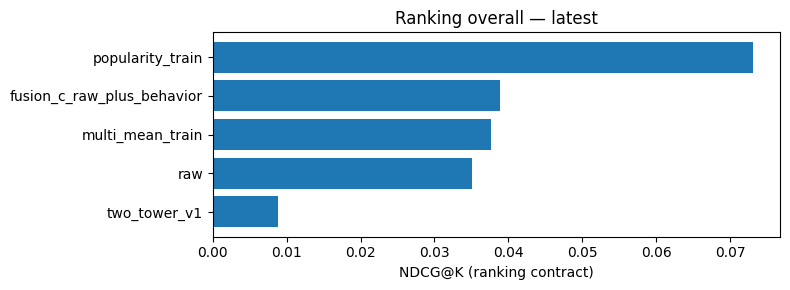

In [10]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

if plt is not None and rank_overall is not None and "NDCG@K" in rank_overall.columns:
    df = rank_overall.sort_values("NDCG@K", ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(df))))
    ax.barh(df["method"], df["NDCG@K"])
    ax.set_xlabel("NDCG@K (ranking contract)")
    ax.set_title(f"Ranking overall — {EVAL_RUN}")
    plt.tight_layout()
    plt.show()
else:
    print("matplotlib not available or ranking table missing; tables above are enough.")